In [ ]:
import string
import pandas as pd
import re
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from nltk.corpus import stopwords
from nltk import pos_tag
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [ ]:
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('averaged_perceptron_tagger_eng')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


True

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/My Drive/R&I/dataset.csv')
print(df.head())
print(df.isnull().sum())

df = df.drop(columns=["Unnamed: 0", "label_num"], axis=1)
print(df.head())


   Unnamed: 0 label                                               text  \
0         605   ham  Subject: enron methanol ; meter # : 988291\r\n...   
1        2349   ham  Subject: hpl nom for january 9 , 2001\r\n( see...   
2        3624   ham  Subject: neon retreat\r\nho ho ho , we ' re ar...   
3        4685  spam  Subject: photoshop , windows , office . cheap ...   
4        2030   ham  Subject: re : indian springs\r\nthis deal is t...   

   label_num  
0          0  
1          0  
2          0  
3          1  
4          0  
Unnamed: 0    0
label         0
text          0
label_num     0
dtype: int64
  label                                               text
0   ham  Subject: enron methanol ; meter # : 988291\r\n...
1   ham  Subject: hpl nom for january 9 , 2001\r\n( see...
2   ham  Subject: neon retreat\r\nho ho ho , we ' re ar...
3  spam  Subject: photoshop , windows , office . cheap ...
4   ham  Subject: re : indian springs\r\nthis deal is t...


In [ ]:
df["clean_text"] = df["text"].str.lower()
df.sample(frac=1).head()

,label,text,clean_text
3792,ham,Subject: covenants - project miracle\r\nas ind...,subject: covenants - project miracle\r\nas ind...
4193,ham,Subject: re : fuel\r\nwe need to discuss furth...,subject: re : fuel\r\nwe need to discuss furth...
3882,ham,Subject: re : first delivery - wagner oil\r\nv...,subject: re : first delivery - wagner oil\r\nv...
4883,ham,Subject: tenaska 2 / 01\r\nwe need to forward ...,subject: tenaska 2 / 01\r\nwe need to forward ...
3478,spam,Subject: re : patchs work better then pillz\r\...,subject: re : patchs work better then pillz\r\...


In [ ]:
string.punctuation

'!"#$%&\'()*+,-./:;<=>?@[\\]^_`{|}~'

In [ ]:
def remove_punctuation(text):
  punctuation = string.punctuation
  return text.translate(str.maketrans("", "", punctuation))


In [ ]:
df["clean_text"] = df["clean_text"].apply(lambda x: remove_punctuation(x))
df.head()

,label,text,clean_text
0,ham,Subject: enron methanol ; meter # : 988291\r\n...,subject enron methanol meter 988291\r\nthis...
1,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",subject hpl nom for january 9 2001\r\n see at...
2,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",subject neon retreat\r\nho ho ho we re aroun...
3,spam,"Subject: photoshop , windows , office . cheap ...",subject photoshop windows office cheap mai...
4,ham,Subject: re : indian springs\r\nthis deal is t...,subject re indian springs\r\nthis deal is to ...


In [ ]:
STOPWORDS = set(stopwords.words("english"))
def remove_stopwords(text):
  return " ".join([word for word in str(text).split() if word not in STOPWORDS])


In [ ]:
df["clean_text"] = df["clean_text"].apply(lambda x: remove_stopwords(x))
df.head()

,label,text,clean_text
0,ham,Subject: enron methanol ; meter # : 988291\r\n...,subject enron methanol meter 988291 follow not...
1,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",subject hpl nom january 9 2001 see attached fi...
2,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",subject neon retreat ho ho ho around wonderful...
3,spam,"Subject: photoshop , windows , office . cheap ...",subject photoshop windows office cheap main tr...
4,ham,Subject: re : indian springs\r\nthis deal is t...,subject indian springs deal book teco pvr reve...


In [ ]:
def remove_numbers(text):
  return re.sub(r"\d+", "", text)

In [ ]:
df["clean_text"] = df["clean_text"].apply(lambda x: remove_numbers(x))
df.head()

,label,text,clean_text
0,ham,Subject: enron methanol ; meter # : 988291\r\n...,subject enron methanol meter follow note gave...
1,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",subject hpl nom january see attached file hp...
2,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",subject neon retreat ho ho ho around wonderful...
3,spam,"Subject: photoshop , windows , office . cheap ...",subject photoshop windows office cheap main tr...
4,ham,Subject: re : indian springs\r\nthis deal is t...,subject indian springs deal book teco pvr reve...


In [ ]:
def remove_urls(text):
  return re.sub(r'http\S+|www\S+|https\S+', ' URL ', text)

In [ ]:
df["clean_text"] = df["clean_text"].apply(lambda x: remove_urls(x))
df.head()

,label,text,clean_text
0,ham,Subject: enron methanol ; meter # : 988291\r\n...,subject enron methanol meter follow note gave...
1,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",subject hpl nom january see attached file hp...
2,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",subject neon retreat ho ho ho around wonderful...
3,spam,"Subject: photoshop , windows , office . cheap ...",subject photoshop windows office cheap main tr...
4,ham,Subject: re : indian springs\r\nthis deal is t...,subject indian springs deal book teco pvr reve...


In [ ]:
def remove_emails(text):
  return re.sub(r'\S+@\S+', ' EMAIL ', text)

In [ ]:
df["clean_text"] = df["clean_text"].apply(lambda x: remove_emails(x))
df.head()

,label,text,clean_text
0,ham,Subject: enron methanol ; meter # : 988291\r\n...,subject enron methanol meter follow note gave...
1,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",subject hpl nom january see attached file hp...
2,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",subject neon retreat ho ho ho around wonderful...
3,spam,"Subject: photoshop , windows , office . cheap ...",subject photoshop windows office cheap main tr...
4,ham,Subject: re : indian springs\r\nthis deal is t...,subject indian springs deal book teco pvr reve...


In [ ]:
def remove_spl_chars(text):
  return re.sub("[^a-zA-Z0-9]", ' ', text)

In [ ]:
df["clean_text"] = df["clean_text"].apply(lambda x: remove_spl_chars(x))
df.head()

,label,text,clean_text
0,ham,Subject: enron methanol ; meter # : 988291\r\n...,subject enron methanol meter follow note gave...
1,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",subject hpl nom january see attached file hp...
2,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",subject neon retreat ho ho ho around wonderful...
3,spam,"Subject: photoshop , windows , office . cheap ...",subject photoshop windows office cheap main tr...
4,ham,Subject: re : indian springs\r\nthis deal is t...,subject indian springs deal book teco pvr reve...


In [ ]:
lemmatizer = WordNetLemmatizer()
wordnet_map = {"N":wordnet.NOUN, "V":wordnet.VERB, "J":wordnet.ADJ, "R":wordnet.ADV}

def lemmatizer_words(text):
  pos_text = pos_tag(text.split())
  return " ".join([lemmatizer.lemmatize(word, wordnet_map.get(pos[0], wordnet.NOUN)) for word, pos in pos_text])

In [ ]:
df['lemmatized_text'] = df["clean_text"].apply(lambda x: lemmatizer_words(x))
df.head()

,label,text,clean_text,lemmatized_text
0,ham,Subject: enron methanol ; meter # : 988291\r\n...,subject enron methanol meter follow note gave...,subject enron methanol meter follow note give ...
1,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",subject hpl nom january see attached file hp...,subject hpl nom january see attach file hplnol...
2,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",subject neon retreat ho ho ho around wonderful...,subject neon retreat ho ho ho around wonderful...
3,spam,"Subject: photoshop , windows , office . cheap ...",subject photoshop windows office cheap main tr...,subject photoshop windows office cheap main tr...
4,ham,Subject: re : indian springs\r\nthis deal is t...,subject indian springs deal book teco pvr reve...,subject indian spring deal book teco pvr reven...


In [ ]:
tfidf = TfidfVectorizer(stop_words="english", max_features=5000)
tfidf_features = tfidf.fit_transform(df["lemmatized_text"])
Fit_text = tfidf_features

In [ ]:
le = LabelEncoder()
Fit_lable = le.fit_transform(df["label"])
print(Fit_lable)

[0 0 0 ... 0 0 1]


label
ham     3672
spam    1499
Name: count, dtype: int64


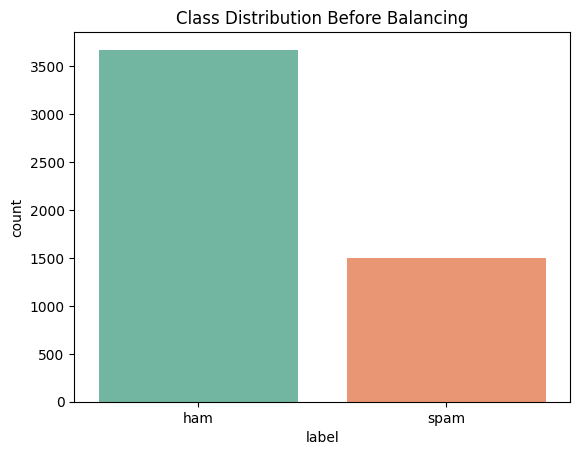

In [ ]:
print(df['label'].value_counts())

sns.countplot(x='label', data=df, palette='Set2', hue='label', legend=False)
plt.title("Class Distribution Before Balancing")
plt.show()

In [ ]:
x = Fit_text
y = Fit_lable
sm = SMOTE(random_state=42)
x_res, y_res = sm.fit_resample(x, y)

print("Before SMOTE:", pd.Series(y).value_counts().to_dict())
print("After SMOTE:", dict(pd.Series(y_res).value_counts()))

Before SMOTE: {0: 3672, 1: 1499}
After SMOTE: {0: np.int64(3672), 1: np.int64(3672)}


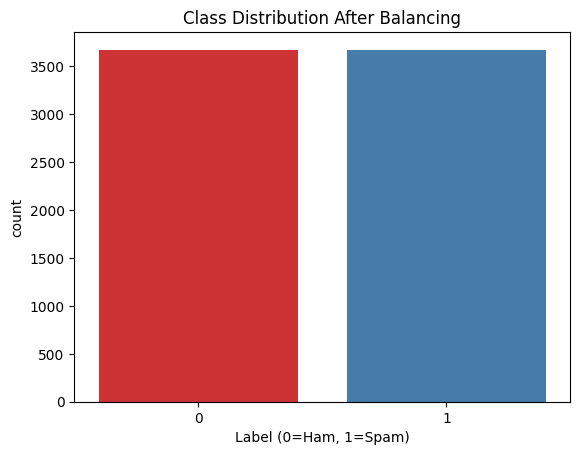

In [ ]:
sns.countplot(x=y_res, palette='Set1', hue=y_res, legend=False)
plt.title("Class Distribution After Balancing")
plt.xlabel("Label (0=Ham, 1=Spam)")
plt.show()

In [ ]:
x = Fit_text
y = Fit_lable

X_train, X_temp, y_train, y_temp = train_test_split(x, y, test_size=0.2, random_state=42)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print("Total samples:", x.shape[0])
print("Training samples:", X_train.shape[0])
print("Validation samples:", X_val.shape[0])
print("Testing samples:", X_test.shape[0])

Total samples: 5171
Training samples: 4136
Validation samples: 517
Testing samples: 518


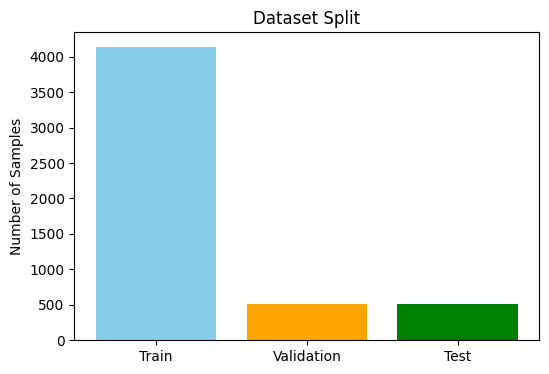

In [ ]:
import matplotlib.pyplot as plt

counts = [X_train.shape[0], X_val.shape[0], X_test.shape[0]]
labels = ['Train', 'Validation', 'Test']

plt.figure(figsize=(6,4))
plt.bar(labels, counts, color=['skyblue', 'orange', 'green'])
plt.title("Dataset Split")
plt.ylabel("Number of Samples")
plt.show()

In [ ]:
df['text_length'] = df['text'].apply(len)
display(df.head())

,label,text,clean_text,lemmatized_text,text_length
0,ham,Subject: enron methanol ; meter # : 988291\r\n...,subject enron methanol meter follow note gave...,subject enron methanol meter follow note give ...,327
1,ham,"Subject: hpl nom for january 9 , 2001\r\n( see...",subject hpl nom january see attached file hp...,subject hpl nom january see attach file hplnol...,97
2,ham,"Subject: neon retreat\r\nho ho ho , we ' re ar...",subject neon retreat ho ho ho around wonderful...,subject neon retreat ho ho ho around wonderful...,2524
3,spam,"Subject: photoshop , windows , office . cheap ...",subject photoshop windows office cheap main tr...,subject photoshop windows office cheap main tr...,414
4,ham,Subject: re : indian springs\r\nthis deal is t...,subject indian springs deal book teco pvr reve...,subject indian spring deal book teco pvr reven...,336


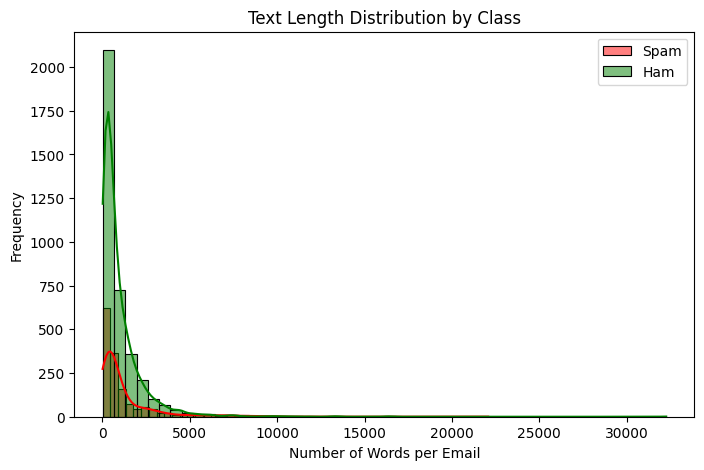

In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df[df['label']=='spam']['text_length'], color='red', label='Spam', kde=True, bins=50)
sns.histplot(df[df['label']=='ham']['text_length'], color='green', label='Ham', kde=True, bins=50)
plt.title("Text Length Distribution by Class")
plt.xlabel("Number of Words per Email")
plt.ylabel("Frequency")
plt.legend()
plt.show()


Accuracy: 0.972972972972973
              precision    recall  f1-score   support

           0       0.98      0.98      0.98       367
           1       0.96      0.95      0.95       151

    accuracy                           0.97       518
   macro avg       0.97      0.97      0.97       518
weighted avg       0.97      0.97      0.97       518

Confusion Matrix:
 [[361   6]
 [  8 143]]


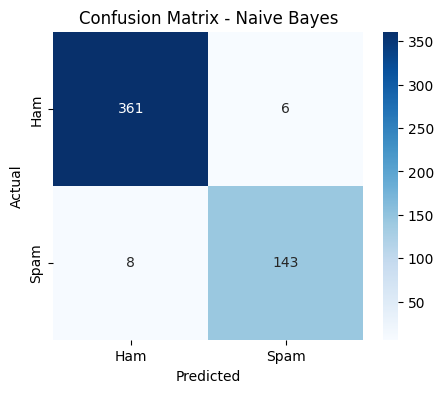

In [ ]:
X = Fit_text
y = Fit_lable

X_train, X_temp, y_train, y_temp = train_test_split(x, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

model = MultinomialNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix - Naive Bayes')
plt.show()

Accuracy: 0.9826254826254827
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       367
           1       0.98      0.96      0.97       151

    accuracy                           0.98       518
   macro avg       0.98      0.98      0.98       518
weighted avg       0.98      0.98      0.98       518

Confusion Matrix:
 [[364   3]
 [  6 145]]


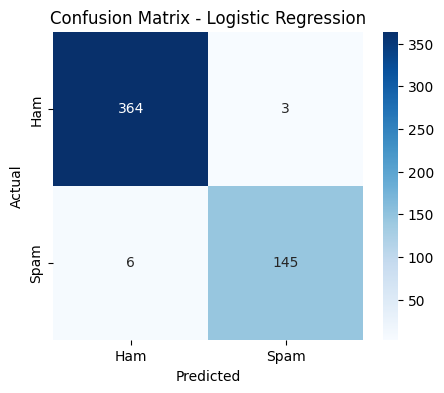

In [ ]:
X = Fit_text
y = Fit_lable

X_train, X_temp, y_train, y_temp = train_test_split(x, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

model = LogisticRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix - Logistic Regression')
plt.show()

Accuracy: 0.9845559845559846
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       367
           1       0.97      0.98      0.97       151

    accuracy                           0.98       518
   macro avg       0.98      0.98      0.98       518
weighted avg       0.98      0.98      0.98       518

Confusion Matrix:
 [[362   5]
 [  3 148]]


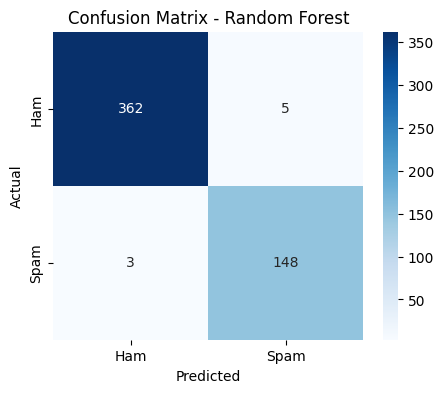

In [ ]:
X = Fit_text
y = Fit_lable

X_train, X_temp, y_train, y_temp = train_test_split(x, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

model = RandomForestClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix - Random Forest')
plt.show()

Accuracy: 0.9633204633204633
              precision    recall  f1-score   support

           0       0.97      0.98      0.97       367
           1       0.95      0.92      0.94       151

    accuracy                           0.96       518
   macro avg       0.96      0.95      0.96       518
weighted avg       0.96      0.96      0.96       518

Confusion Matrix:
 [[360   7]
 [ 12 139]]


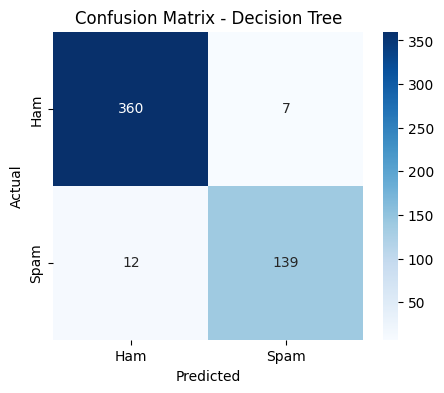

In [ ]:
X = Fit_text
y = Fit_lable

X_train, X_temp, y_train, y_temp = train_test_split(x, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix - Decision Tree')
plt.show()

Accuracy: 0.9903474903474904
              precision    recall  f1-score   support

           0       0.99      1.00      0.99       367
           1       0.99      0.97      0.98       151

    accuracy                           0.99       518
   macro avg       0.99      0.99      0.99       518
weighted avg       0.99      0.99      0.99       518

Confusion Matrix:
 [[366   1]
 [  4 147]]


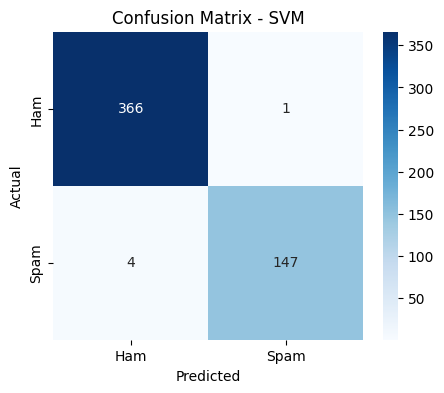

In [ ]:
X = Fit_text
y = Fit_lable

X_train, X_temp, y_train, y_temp = train_test_split(x, y, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

model = LinearSVC()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Ham', 'Spam'], yticklabels=['Ham', 'Spam'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.title('Confusion Matrix - SVM')
plt.show()